# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Imapct Of Social Media On Health Dataset](https://www.kaggle.com/datasets/sumeakash/impact-of-social-media-on-health/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/sumeakash/impact-of-social-media-on-health/Social_media_impact_on_life.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Social_media_impact_on_life.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive
1704,705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5.0,Negative


## Shape of our dataset

In [5]:
df.shape

(1705, 11)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

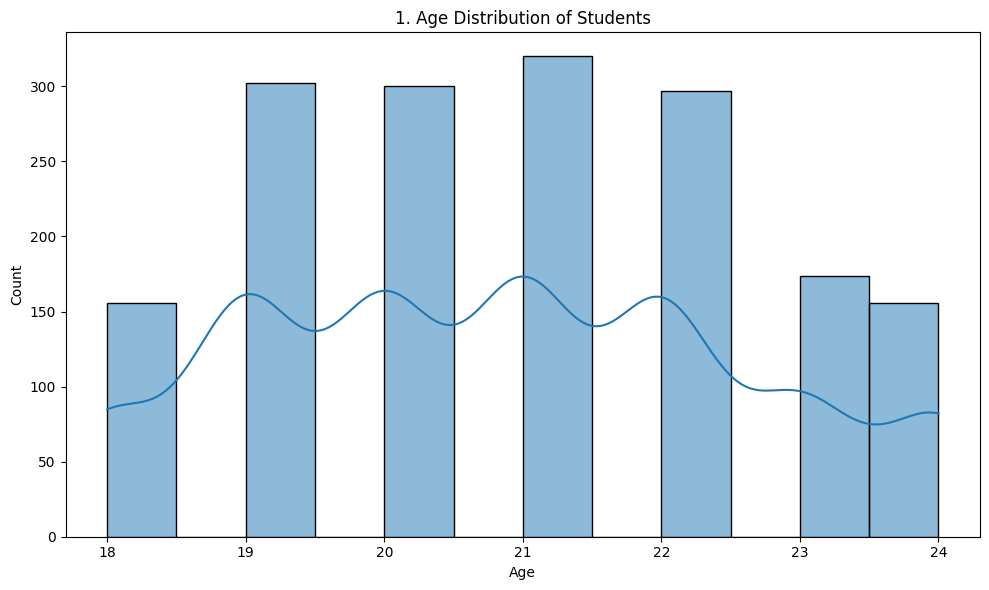

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Students')
show_fig()
plot_no += 1

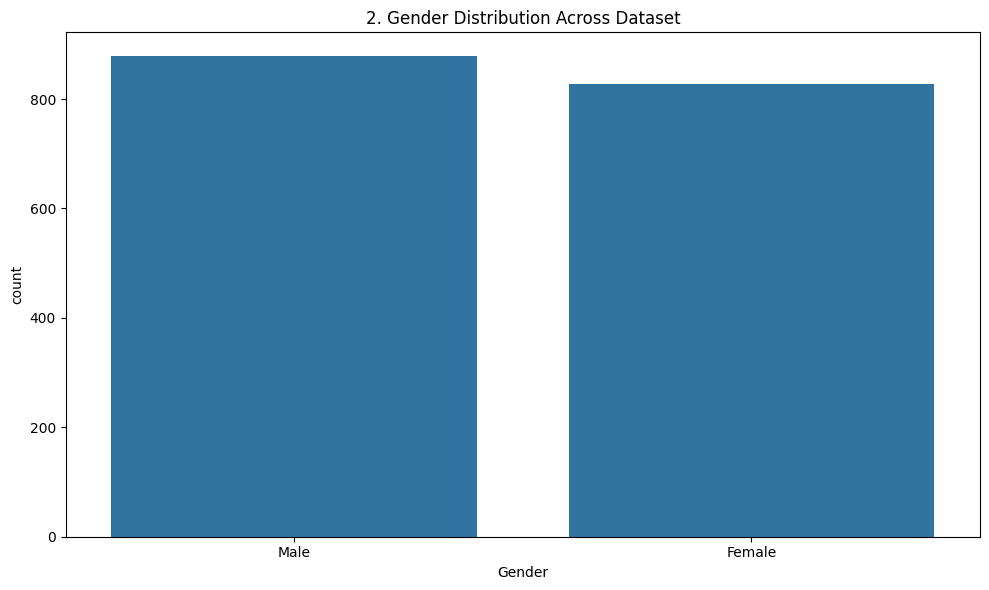

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title(f'{plot_no}. Gender Distribution Across Dataset')
show_fig()
plot_no += 1

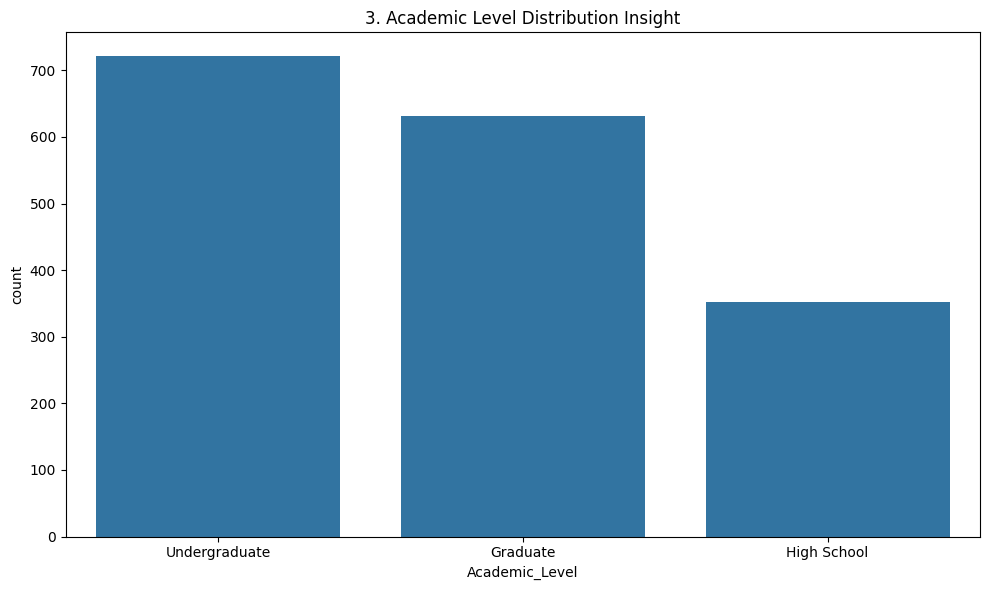

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Academic_Level', data=df)
plt.title(f'{plot_no}. Academic Level Distribution Insight')
show_fig()
plot_no += 1

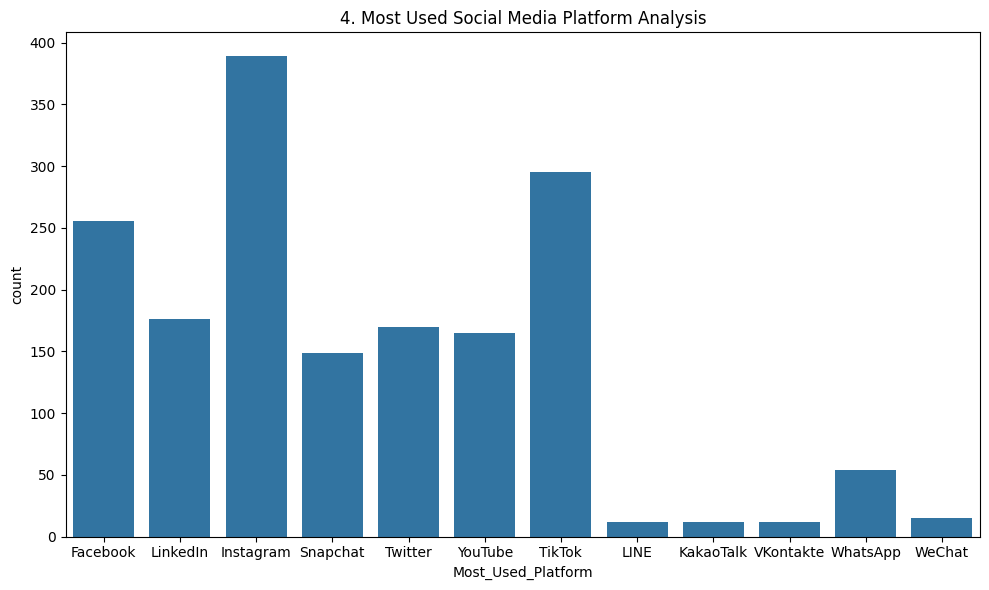

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Most_Used_Platform', data=df)
plt.title(f'{plot_no}. Most Used Social Media Platform Analysis')
show_fig()
plot_no += 1

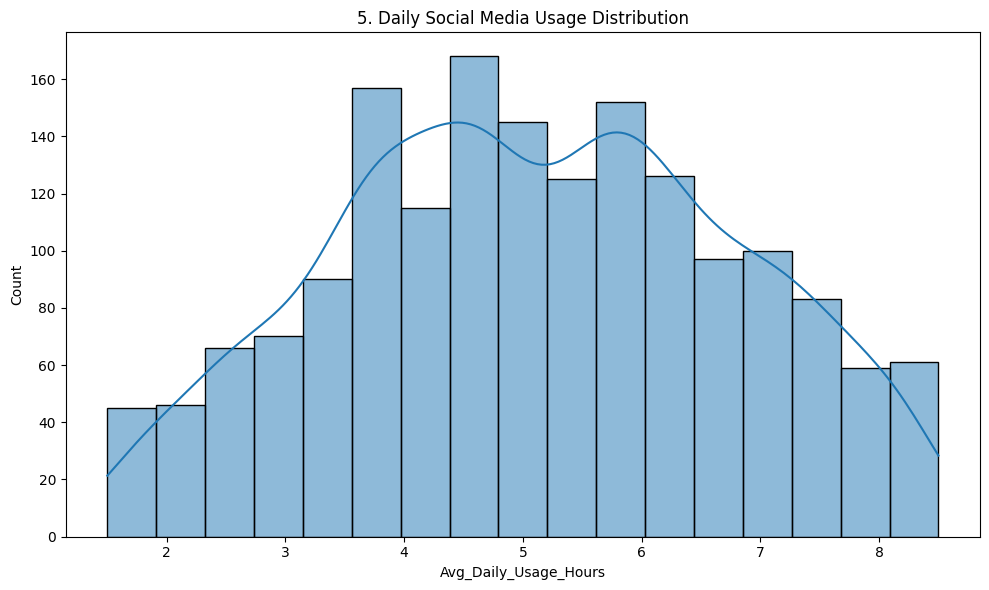

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Avg_Daily_Usage_Hours'], kde=True)
plt.title(f'{plot_no}. Daily Social Media Usage Distribution')
show_fig()
plot_no += 1

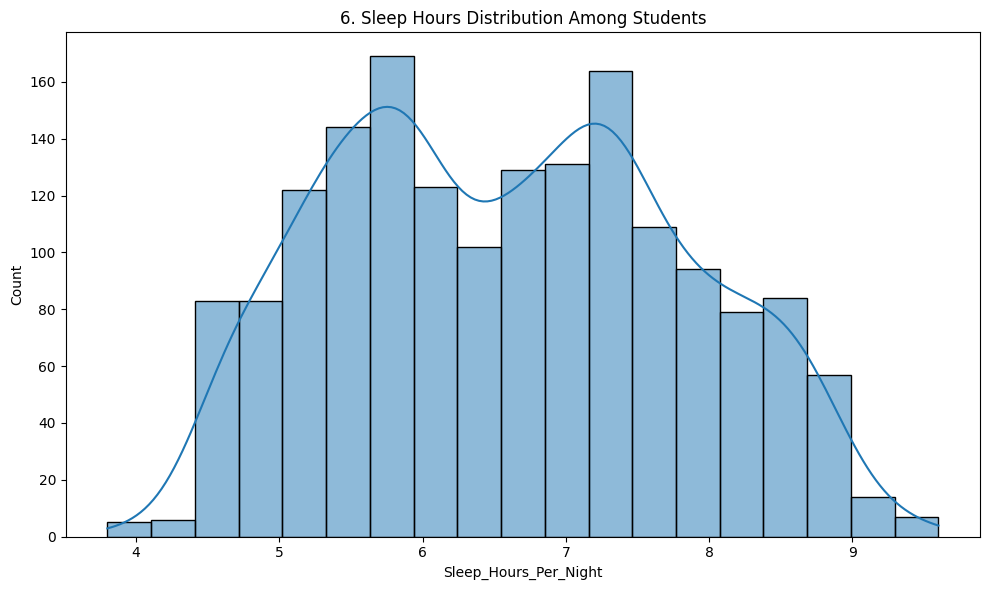

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Sleep_Hours_Per_Night'], kde=True)
plt.title(f'{plot_no}. Sleep Hours Distribution Among Students')
show_fig()
plot_no += 1

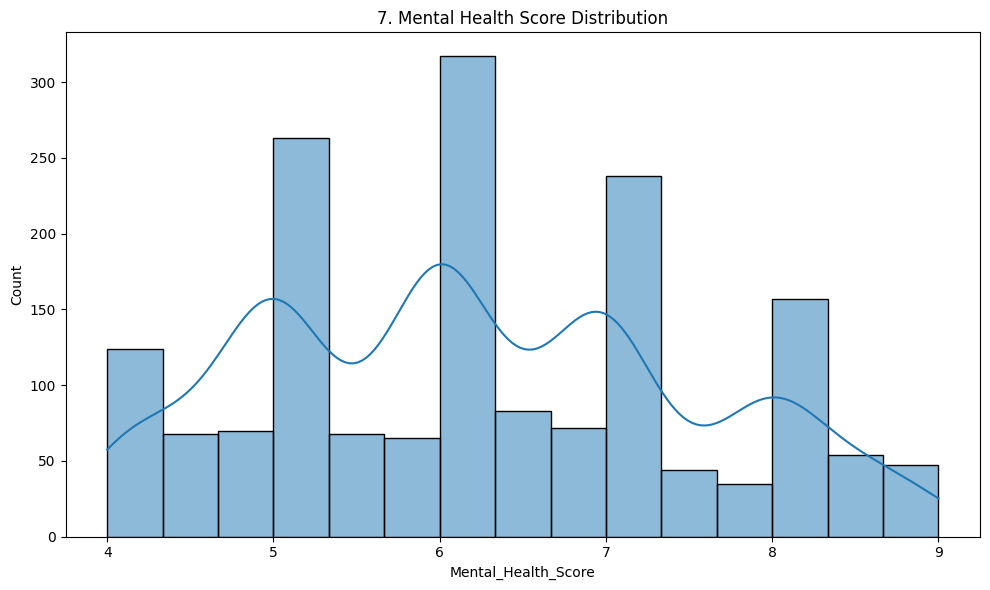

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.title(f'{plot_no}. Mental Health Score Distribution')
show_fig()
plot_no += 1

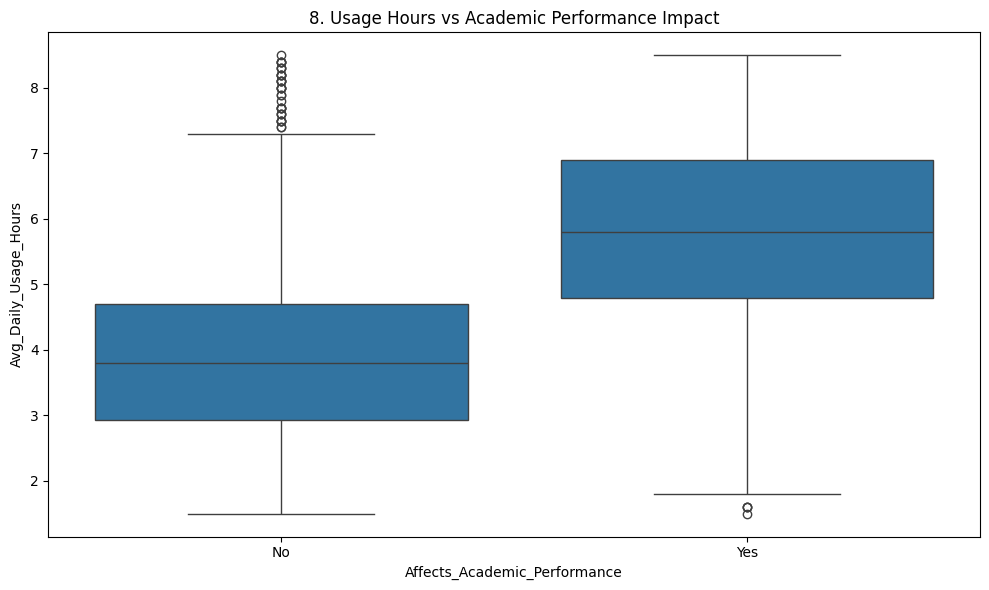

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Affects_Academic_Performance', y='Avg_Daily_Usage_Hours', data=df)
plt.title(f'{plot_no}. Usage Hours vs Academic Performance Impact')
show_fig()
plot_no += 1

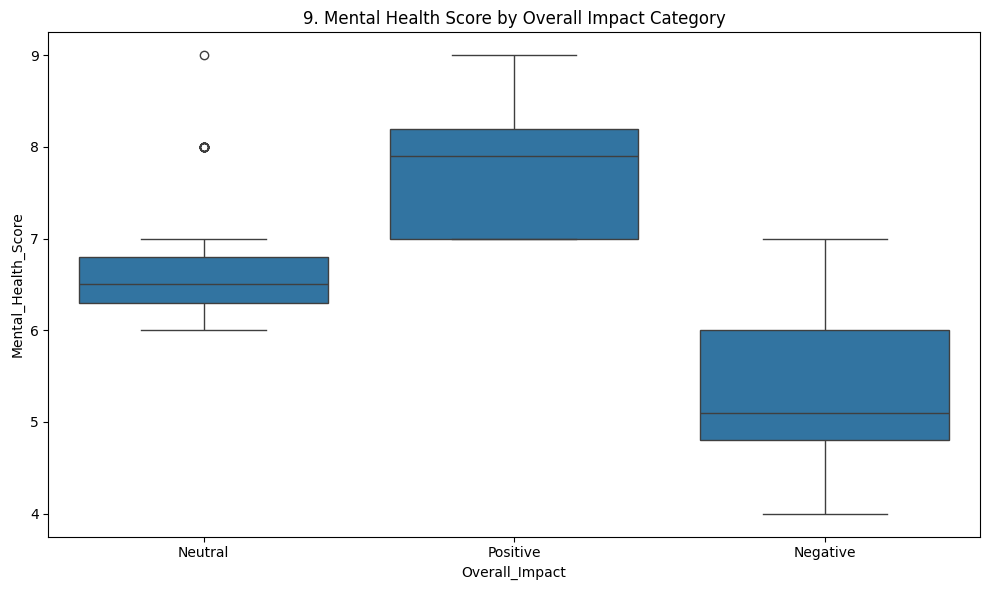

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Overall_Impact', y='Mental_Health_Score', data=df)
plt.title(f'{plot_no}. Mental Health Score by Overall Impact Category')
show_fig()
plot_no += 1

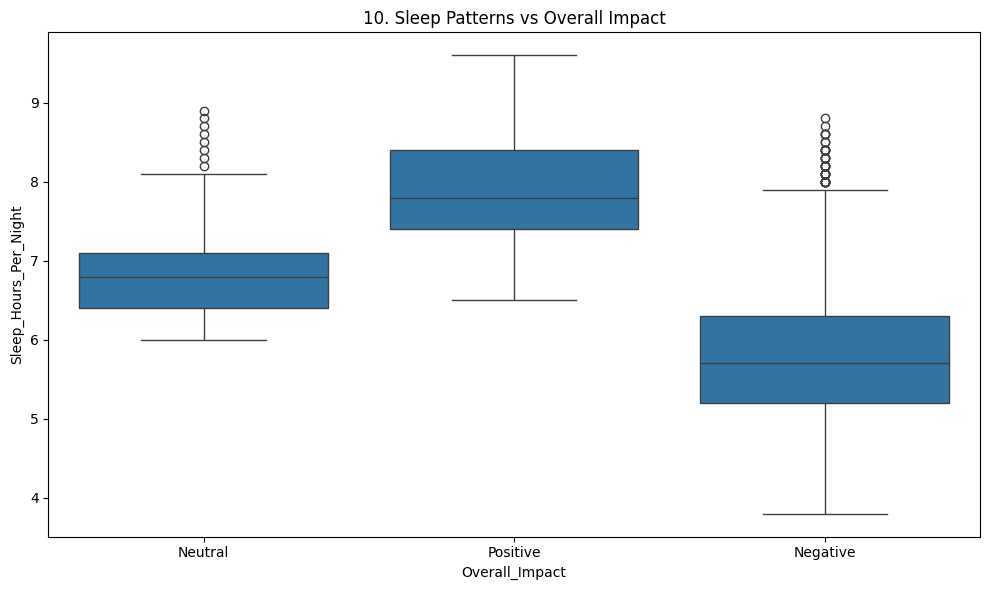

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Overall_Impact', y='Sleep_Hours_Per_Night', data=df)
plt.title(f'{plot_no}. Sleep Patterns vs Overall Impact')
show_fig()
plot_no += 1

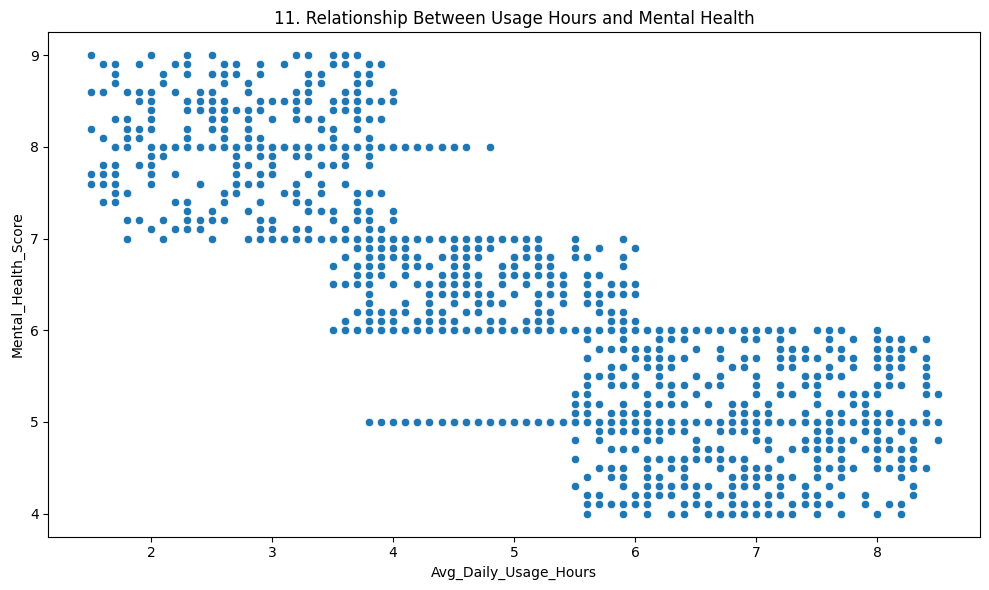

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)
plt.title(f'{plot_no}. Relationship Between Usage Hours and Mental Health')
show_fig()
plot_no += 1

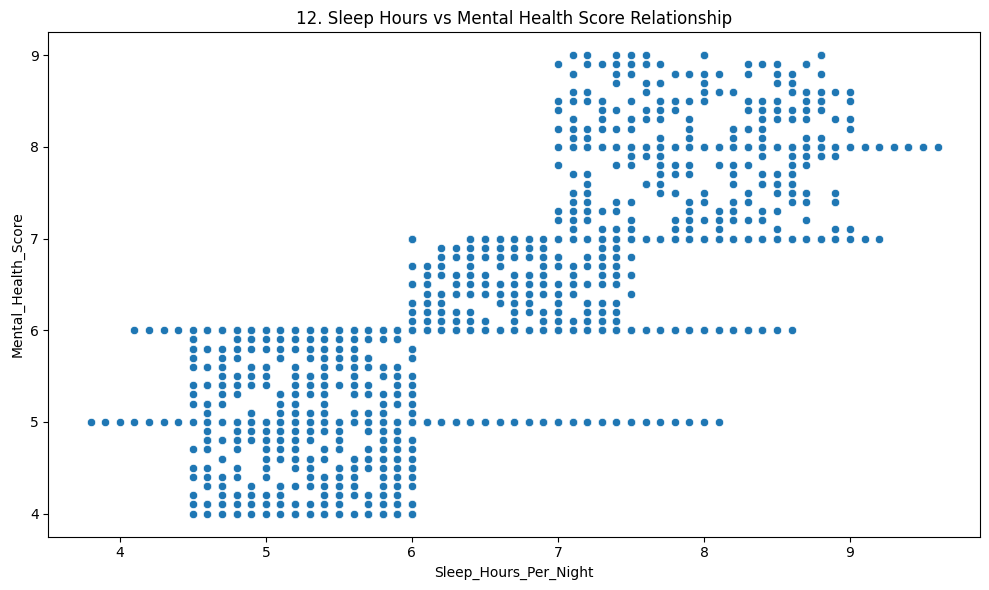

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)
plt.title(f'{plot_no}. Sleep Hours vs Mental Health Score Relationship')
show_fig()
plot_no += 1

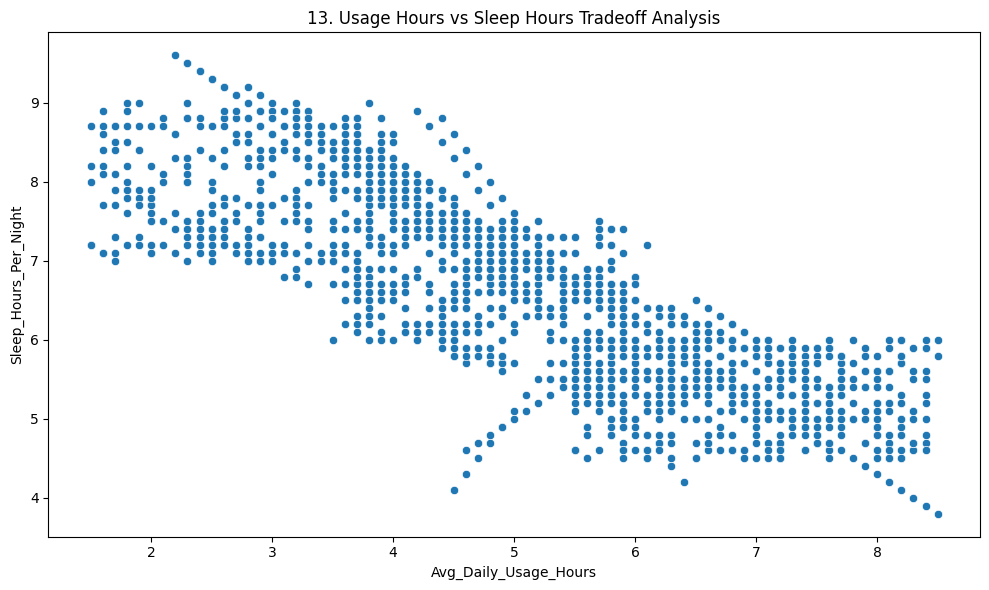

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night', data=df)
plt.title(f'{plot_no}. Usage Hours vs Sleep Hours Tradeoff Analysis')
show_fig()
plot_no += 1

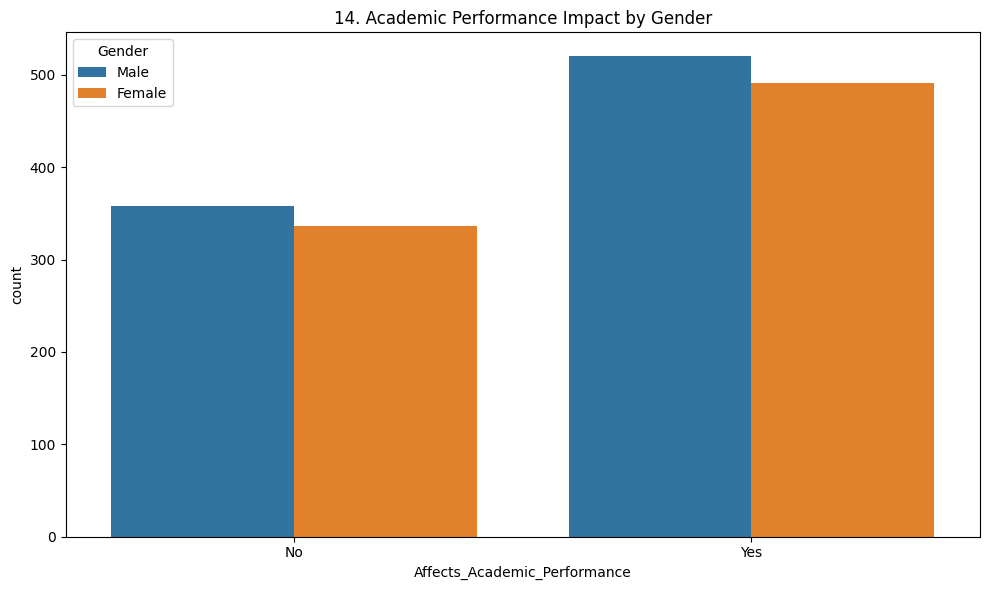

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Affects_Academic_Performance', hue='Gender', data=df)
plt.title(f'{plot_no}. Academic Performance Impact by Gender')
show_fig()
plot_no += 1

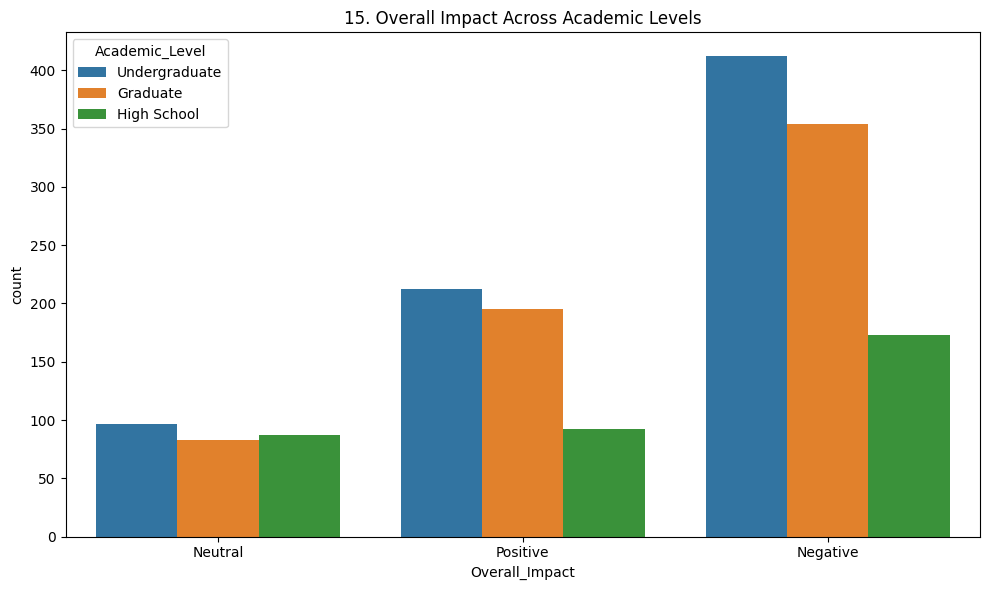

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Overall_Impact', hue='Academic_Level', data=df)
plt.title(f'{plot_no}. Overall Impact Across Academic Levels')
show_fig()
plot_no += 1

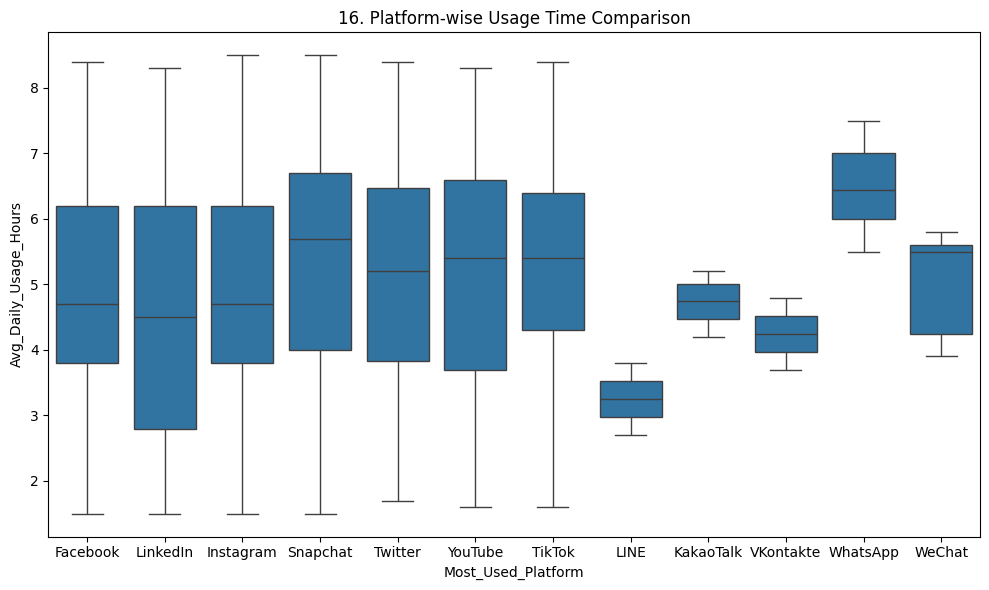

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Most_Used_Platform', y='Avg_Daily_Usage_Hours', data=df)
plt.title(f'{plot_no}. Platform-wise Usage Time Comparison')
show_fig()
plot_no += 1

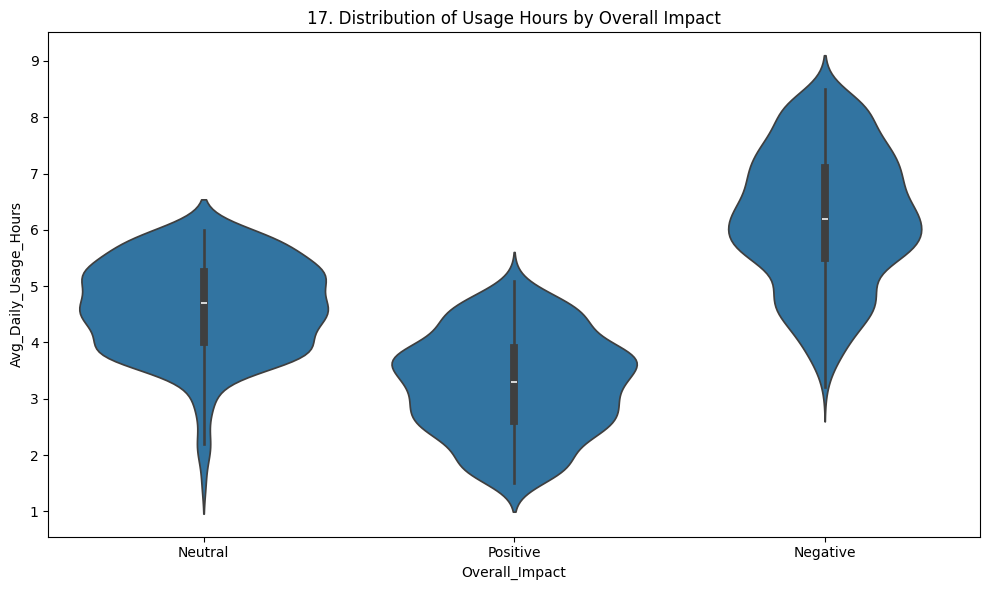

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Overall_Impact', y='Avg_Daily_Usage_Hours', data=df)
plt.title(f'{plot_no}. Distribution of Usage Hours by Overall Impact')
show_fig()
plot_no += 1

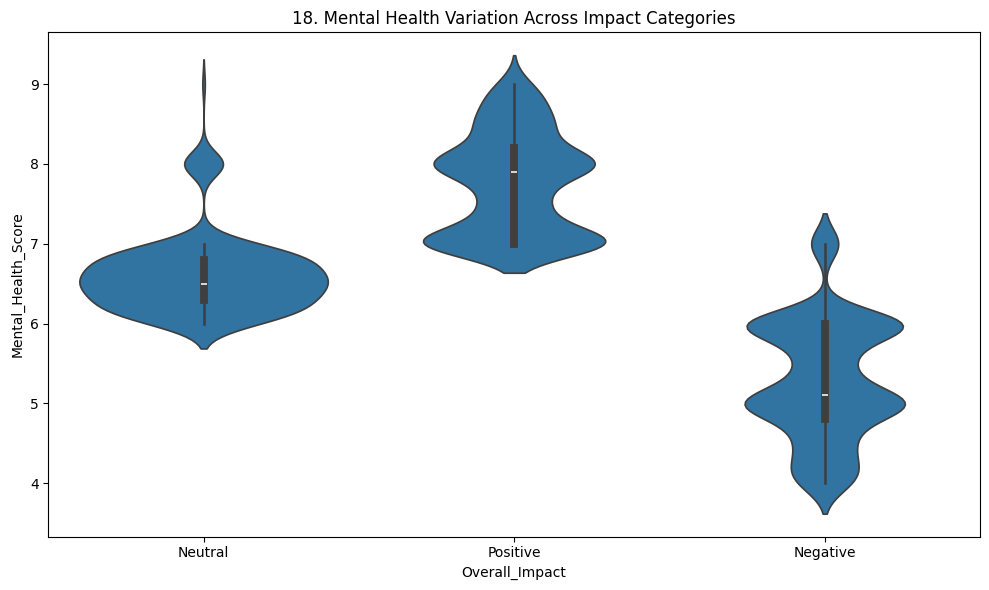

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Overall_Impact', y='Mental_Health_Score', data=df)
plt.title(f'{plot_no}. Mental Health Variation Across Impact Categories')
show_fig()
plot_no += 1

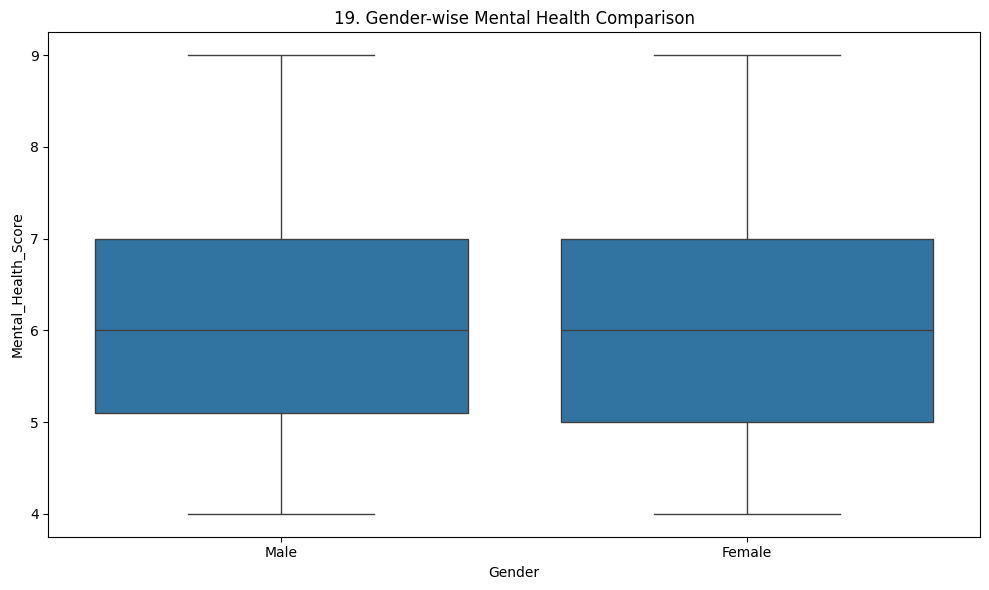

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Gender', y='Mental_Health_Score', data=df)
plt.title(f'{plot_no}. Gender-wise Mental Health Comparison')
show_fig()
plot_no += 1

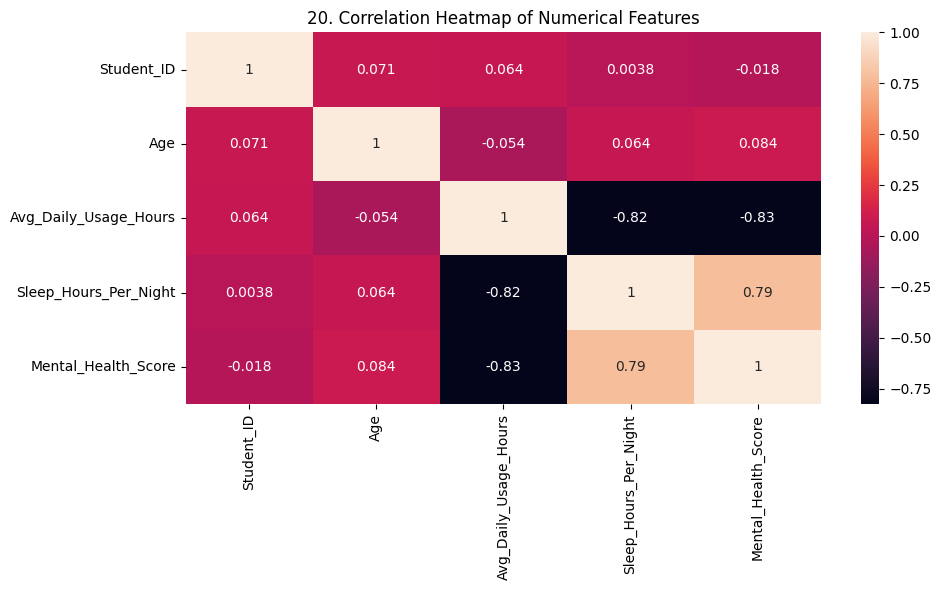

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## create a copy of dataset

In [33]:
data = df.copy()

## encode categorical columns

In [34]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## define features and target

In [35]:
X = data.drop('Overall_Impact', axis=1)
y = data['Overall_Impact']

## split dataset into training and testing

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train logistic regression model

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [39]:
y_pred = model.predict(X_test)

## calculate accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9032258064516129


## create confusion matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

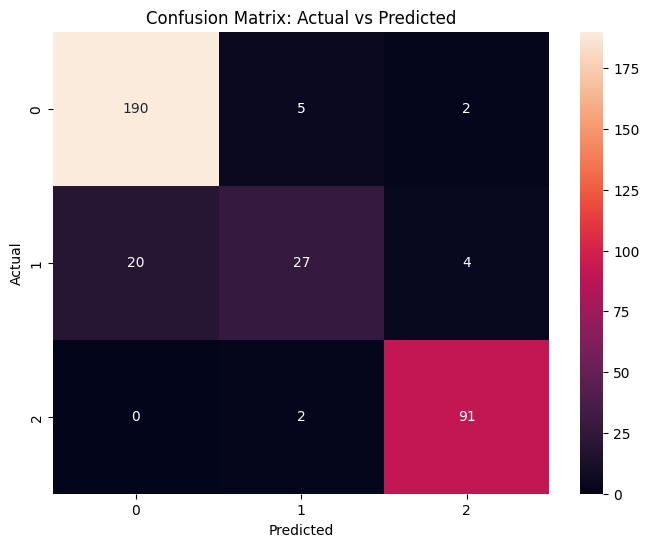

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix: Actual vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()